In [1]:
import numpy as np
import scipy as sp
#import pyccl as ccl
import math
import matplotlib.pyplot as plt

# open data 

Text(0.5, 0, 'm-detect < m')

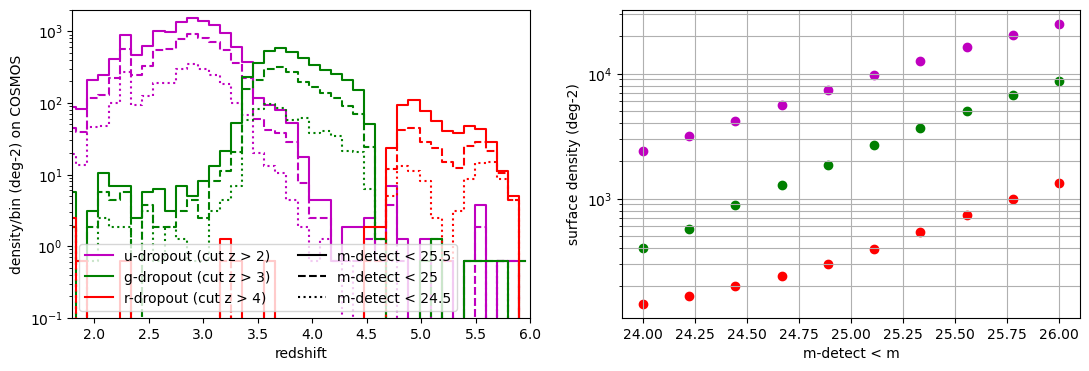

In [2]:
plt.figure(figsize=(13,4))
plt.subplot(121)
S=1.6
N_zm_u = np.load(f'../target_selection/photom_redshift_distribution/COSMOS_LBG_udropout.npz')
plt.step(N_zm_u['z_center'], np.sum(N_zm_u['object_count'][:,N_zm_u['mag_center'] < 25.5], axis=1)/S, where='mid', color = 'm')
plt.step(N_zm_u['z_center'], np.sum(N_zm_u['object_count'][:,N_zm_u['mag_center'] < 25], axis=1)/S, '--',where='mid', color = 'm')
plt.step(N_zm_u['z_center'], np.sum(N_zm_u['object_count'][:,N_zm_u['mag_center'] < 24.5], axis=1)/S, ':',where='mid', color = 'm')

N_zm_g = np.load(f'../target_selection/photom_redshift_distribution/COSMOS_LBG_gdropout.npz')
plt.step(N_zm_g['z_center'], np.sum(N_zm_g['object_count'][:,N_zm_g['mag_center'] < 25.5], axis=1)/S, '-',where='mid', color = 'g')
plt.step(N_zm_g['z_center'], np.sum(N_zm_g['object_count'][:,N_zm_g['mag_center'] < 25], axis=1)/S,'--', where='mid',color = 'g')
plt.step(N_zm_g['z_center'], np.sum(N_zm_g['object_count'][:,N_zm_g['mag_center'] < 24.5], axis=1)/S, ':',where='mid',color = 'g')

N_zm_r = np.load(f'../target_selection/photom_redshift_distribution/COSMOS_LBG_rdropout.npz')
plt.step(N_zm_r['z_center'], np.sum(N_zm_r['object_count'][:,N_zm_r['mag_center'] < 25.5], axis=1)/S,'-', where='mid',color = 'r')
plt.step(N_zm_r['z_center'], np.sum(N_zm_r['object_count'][:,N_zm_r['mag_center'] < 25], axis=1)/S, '--',where='mid',color = 'r')
plt.step(N_zm_r['z_center'], np.sum(N_zm_r['object_count'][:,N_zm_r['mag_center'] < 24.5], axis=1)/S,':',where='mid', color = 'r')

plt.plot([], [], 'm', label = 'u-dropout (cut z > 2)')

plt.plot([], [], 'g', label = 'g-dropout (cut z > 3)')

plt.plot([], [], 'r', label = 'r-dropout (cut z > 4)')

plt.plot([], [], '-k', label = 'm-detect < 25.5')

plt.plot([], [], '--k', label = 'm-detect < 25')

plt.plot([], [], ':k', label = 'm-detect < 24.5')
plt.ylim(0.1, 2000)
plt.yscale('log')
plt.xlabel('redshift')
plt.ylabel('density/bin (deg-2) on COSMOS')
plt.legend(ncols=2)
plt.xlim(1.8, 6)

plt.subplot(122)
for rmag in np.linspace(24, 26, 10):
    Ntot = np.sum(np.sum(N_zm_u['object_count'][:,N_zm_u['mag_center'] < rmag], axis=1))
    plt.scatter(rmag, Ntot/S, c='m')
for rmag in np.linspace(24, 26, 10):
    Ntot = np.sum(np.sum(N_zm_g['object_count'][:,N_zm_g['mag_center'] < rmag], axis=1))
    plt.scatter(rmag, Ntot/S, c='g')
for rmag in np.linspace(24, 26, 10):
    Ntot = np.sum(np.sum(N_zm_r['object_count'][:,N_zm_r['mag_center'] < rmag], axis=1))
    plt.scatter(rmag, Ntot/S, c='r')
plt.yscale('log')

plt.plot([], [], 'm', label = 'u-dropout')
plt.plot([], [], 'g', label = 'g-dropout')
plt.plot([], [], 'r', label = 'r-dropout')
plt.grid(which='both')
plt.ylabel('surface density (deg-2)')
plt.xlabel('m-detect < m')

## Exposure time
First let's have a function which gives the time of exposure for a magnitude m object.

The equation is the following: $t_{\rm wst}(m\vert {\rm SNR})=\left\lceil \frac{t_{\rm ref\, desi}\;S_{\rm desi}}{t_{1\,\rm exp}\;S_{\rm wst}}\left(\frac{I(m_{\rm ref})\;{\rm SNR}}{\eta_{\rm wst/desi}\;I(m)\;{\rm SNR}_{\rm ref}}\right)^2\right\rceil\,t_{1\,\rm exp}$

In [1]:
Swst=math.pi*12**2 #wst is a 12 meters

def t_tel(m,t1exp=15,eta=1.2,Stel=Swst,SNR=10,tref=2*60, mref=24.5, SNRref=10):

    def I(m):#flux as function of magnitude. To be checked.
        I0=1# anyway we will consider ratio of flux
        return I0*10**(-0.4*m)
    
    Sdesi=math.pi*4**2 #desi is a 4 meter
    

    x=tref/t1exp *Sdesi/Stel*(I(mref)*SNR/(eta*I(m)*SNRref))**2
    
    return math.ceil(x)*t1exp #ceil is partie entiere sup


NameError: name 'math' is not defined

In [ ]:
plt.figure(dpi=200)
m=np.linspace(24,26,1000)
tm=[t_tel(m1,tref=1*60, mref=24.5, SNRref=10) for m1 in m]
plt.plot(m,tm,color='olive',label='1hour for a m=24.5 galaxy with DESI',linestyle='--')

tm=[t_tel(m1,tref=2*60, mref=24.5, SNRref=10) for m1 in m]
plt.plot(m,tm,color='cornflowerblue',label='2hours for a m=24.5 galaxy with DESI',linestyle='-')

tm=[t_tel(m1,tref=3*60, mref=24.5, SNRref=10) for m1 in m]
plt.plot(m,tm,color='crimson',label='3hours for a m=24.5 galaxy with DESI',linestyle='-.')

plt.plot([24,26],[60,60],linestyle='dotted',color='dimgrey')

plt.xlabel('Magnitude $m$')
plt.ylabel('Exposure time in [min] for SNR=10')
plt.ylim(0,121)
plt.xlim(24,26)
plt.yticks([0,15,30,45,60,75,90,105,120])
plt.legend()
plt.savefig('../figures/exposure_time_from_desi.pdf',bbox_inches='tight')

## Survey time 
We have a fixed survey time, 5years, which gives a fix dark time available. 


In [5]:
alpha_year_min=365*21/28*9*0.8*60 #year in day, days of dt, hour per day, 80% due to weather, 60 minutes per hour
year=5
Tsur_dt=year*alpha_year_min 
print(Tsur_dt,' min of dark time over ',year, ' years')

eta_til=0.95
fsky=0.4
Nfib=30*10**3


fov=3
A=15000
print('time per deg2 of dt',Tsur_dt*fov/A )

591300.0  min of dark time over  5  years
time per deg2 of dt 118.26


In [6]:
def Tsur(m_array,Phi_m,texp_m,m_max):
    '''
    Time allocated for the observation of a tracer up to a magnitude m_max
    
    m_array is the array of magnitude
    Phi_m the target density for a certain magnitude (per bin of magnitude) in deg-2
    texp_m the array of exposure time for a given magnitude
    m_max the maximal magnitude to be considered
    '''
    prefact=fsky*41253*eta_til/Nfib
    sel=((m_array<m_max))
    integ=np.sum(Phi_m[sel]*texp_m[sel])
    return prefact*integ


In [10]:
print('-----LBG u---------')
m_array=N_zm_u['mag_center']
Phi_m=np.sum(N_zm_u['object_count'], axis=0)/S
texp_m=np.array([t_tel(m,tref=2*60, mref=24.5, SNRref=10) for m in m_array])
mmax=26

Tu=Tsur(m_array,Phi_m,texp_m,m_max=mmax)
print(round(Tu,0),' min of DT')

print(round(Tu/Tsur_dt*100,0),' % of 5years of DT for lbg-u up to ',mmax)

print('')
print('-----LBG g---------')
m_array=N_zm_g['mag_center']
Phi_m=np.sum(N_zm_g['object_count'], axis=0)/S
texp_m=np.array([t_tel(m,tref=3*60, mref=24.5, SNRref=10) for m in m_array])
mmax=26

Tg=Tsur(m_array,Phi_m,texp_m,m_max=mmax)
print(round(Tg,0),' min of DT')

print(round(Tg/Tsur_dt*100,0),' % of 5years of DT for lbg-g up to ',mmax)


print('')
print('-----LBG r---------')
m_array=N_zm_r['mag_center']
Phi_m=np.sum(N_zm_r['object_count'], axis=0)/S
texp_m=np.array([t_tel(m,tref=3*60, mref=24.5, SNRref=10) for m in m_array])
mmax=26
Tr=Tsur(m_array,Phi_m,texp_m,m_max=mmax)
print(round(Tr,0),' min of DT')

print(round(Tr/Tsur_dt*100,0),' % of 5years of DT for lbg-r up to ',mmax)

print('')
print('-----All-----------')
print(round((Tu+Tg+Tr)/Tsur_dt*100,0),' % of 5 years of DT for LBG')

-----LBG u---------
766852.0  min of DT
130.0  % of 5years of DT for lbg-u up to  26

-----LBG g---------
430751.0  min of DT
73.0  % of 5years of DT for lbg-g up to  26

-----LBG r---------
66070.0  min of DT
11.0  % of 5years of DT for lbg-r up to  26

-----All-----------
214.0  % of 5 years of DT for LBG
